Install Dependencies and Dataset

In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
os.environ['KAGGLE_USERNAME'] = 'group15aiml'
os.environ['KAGGLE_KEY'] = 'KGAT_7d65874aaa633b5a0fcb994c3b1b837e'

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Install Kaggle
!pip install -q kaggle
# Download flickr8k
!kaggle datasets download -d adityajn105/flickr8k
!unzip -q flickr8k.zip -d /content/flickr8k

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
100% 1.04G/1.04G [00:09<00:00, 120MB/s]



In [5]:
!pip install -q git+https://github.com/openai/CLIP.git

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.4 MB/s eta 0:00:00


In [6]:
print(os.listdir("/content/flickr8k"))

image_dir = "/content/flickr8k/Images"

print("Number of images:", len(os.listdir(image_dir)))

['Images', 'captions.txt']
Number of images: 8091


In [7]:
captions = pd.read_csv("/content/flickr8k/captions.txt")

print(captions.shape)
captions.head()

(40455, 2)


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


Mount Flickr8k to Drive

In [8]:
PROJECT_DIR = "/content/drive/MyDrive/MMRetrieval"
os.makedirs(PROJECT_DIR, exist_ok=True)

In [9]:
!cp -r /content/flickr8k \
      /content/drive/MyDrive/MMRetrieval/

In [10]:
!ls "/content/drive/MyDrive/MMRetrieval/flickr8k"

captions.txt  Images


Divide to 4 Subsets

In [11]:
import clip
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess = clip.load("ViT-B/32", device=device)

print("Device:", device)

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 164MiB/s]


Device: cuda


In [12]:
captions["image"].nunique()

8091

In [13]:
unique_images = captions["image"].unique()

image_subsets = np.array_split(unique_images, 4)

for i, subset_imgs in enumerate(image_subsets):

    subset_df = captions[
        captions["image"].isin(subset_imgs)
    ].reset_index(drop=True)

    print(
        f"Subset {i+1}:",
        subset_df['image'].nunique(),
        "images,",
        len(subset_df),
        "captions"
    )

Subset 1: 2023 images, 10115 captions
Subset 2: 2023 images, 10115 captions
Subset 3: 2023 images, 10115 captions
Subset 4: 2022 images, 10110 captions


Save Subsets to Drive

In [14]:
SAVE_DIR = "/content/drive/MyDrive/Flickr8k_Subsets"

os.makedirs(SAVE_DIR, exist_ok=True)

In [15]:
for i, subset_imgs in enumerate(image_subsets):

    subset_df = captions[
        captions["image"].isin(subset_imgs)
    ].reset_index(drop=True)

    save_path = f"{SAVE_DIR}/subset_{i+1}.csv"

    subset_df.to_csv(
        save_path,
        index=False
    )

    print("Saved:", save_path)

Saved: /content/drive/MyDrive/Flickr8k_Subsets/subset_1.csv
Saved: /content/drive/MyDrive/Flickr8k_Subsets/subset_2.csv
Saved: /content/drive/MyDrive/Flickr8k_Subsets/subset_3.csv
Saved: /content/drive/MyDrive/Flickr8k_Subsets/subset_4.csv


In [16]:
# Save Image Lists
import pickle

for i, subset_imgs in enumerate(image_subsets):

    with open(
        f"{SAVE_DIR}/subset_{i+1}_images.pkl",
        "wb"
    ) as f:

        pickle.dump(
            list(subset_imgs),
            f
        )

Load Subset

In [25]:
# Load Subset 1
subset = pd.read_csv(
    "/content/drive/MyDrive/Flickr8k_Subsets/subset_1.csv"
)

print(
    subset["image"].nunique()
)

print(
    len(subset)
)

2023
10115


In [27]:
# Load CLIP
import clip
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess = clip.load(
    "ViT-B/32",
    device=device
)

print(device)

cuda


In [43]:
# Generate Image Embeddings
from PIL import Image
from tqdm import tqdm
import numpy as np

image_embeddings = []
image_ids = []

subset_images = subset["image"].unique()

print("Subset Images:", len(subset_images))

for img_name in tqdm(subset_images):

    img_path = f"/content/flickr8k/Images/{img_name}"

    image = preprocess(
        Image.open(img_path).convert("RGB")
    ).unsqueeze(0).to(device)

    with torch.no_grad():

        feat = model.encode_image(image)

        feat /= feat.norm(
            dim=-1,
            keepdim=True
        )

    image_embeddings.append(
        feat.cpu().numpy()[0]
    )

    image_ids.append(img_name)

image_embeddings = np.array(
    image_embeddings,
    dtype=np.float32
)

print(image_embeddings.shape)

Subset Images: 2023


100%|██████████| 2023/2023 [00:32<00:00, 61.81it/s]

(2023, 512)


In [44]:
os.makedirs(
    "/content/drive/MyDrive/MMRetrieval/embeddings",
    exist_ok=True
)

print(os.listdir("/content/drive/MyDrive/MMRetrieval"))

['flickr8k', 'embeddings']


In [45]:
# Save Image Embeddings
np.save(
    "/content/drive/MyDrive/MMRetrieval/embeddings/subset1_image_embeddings.npy",
    image_embeddings
)

In [46]:
# Create Caption Embeddings
caption_embeddings = []

for caption in tqdm(subset["caption"]):

    tokens = clip.tokenize(
        [caption],
        truncate=True
    ).to(device)

    with torch.no_grad():

        feat = model.encode_text(tokens)

        feat /= feat.norm(
            dim=-1,
            keepdim=True
        )

    caption_embeddings.append(
        feat.cpu().numpy()[0]
    )

caption_embeddings = np.array(
    caption_embeddings,
    dtype=np.float32
)

print(caption_embeddings.shape)

100%|██████████| 10115/10115 [01:42<00:00, 98.29it/s] 


(10115, 512)


In [47]:
# Save Caption Embeddings
np.save(
    "/content/drive/MyDrive/MMRetrieval/embeddings/subset1_caption_embeddings.npy",
    caption_embeddings
)

In [48]:
# Saving Metadata
with open(
    "/content/drive/MyDrive/MMRetrieval/embeddings/subset1_image_ids.pkl",
    "wb"
) as f:

    pickle.dump(image_ids, f)

subset.to_csv(
    "/content/drive/MyDrive/MMRetrieval/embeddings/subset1_metadata.csv",
    index=False
)

In [49]:
with open(
    "/content/drive/MyDrive/MMRetrieval/embeddings/subset1_image_ids.pkl",
    "wb"
) as f:
    pickle.dump(image_ids, f)

subset.to_csv(
    "/content/drive/MyDrive/MMRetrieval/embeddings/subset1_metadata.csv",
    index=False
)

Retreival Similarity

In [50]:
# Image to Text Retrieval
similarity_matrix = (
    image_embeddings @ caption_embeddings.T
)

print(similarity_matrix.shape)

(2023, 10115)


In [51]:
# Top 5 captions
image_idx = 0

scores = similarity_matrix[image_idx]

top5 = scores.argsort()[-5:][::-1]

for rank, cap_idx in enumerate(top5):

    print(
        f"Top-{rank+1}:",
        subset.iloc[cap_idx]["caption"]
    )

Top-1: A little girl in a pink dress going into a wooden cabin .
Top-2: A little girl climbing the stairs to her playhouse .
Top-3: A little girl climbing into a wooden playhouse .
Top-4: A child in a pink dress is climbing up a set of stairs in an entry way .
Top-5: A barefoot red-headed girl jumping over a rail .


In [52]:
# Text to Image Retrevial
text_idx = 0

query = caption_embeddings[text_idx]

scores = query @ image_embeddings.T

top5 = scores.argsort()[-5:][::-1]

for rank, img_idx in enumerate(top5):

    print(
        f"Top-{rank+1}:",
        image_ids[img_idx]
    )

Top-1: 1000268201_693b08cb0e.jpg
Top-2: 1481062342_d9e34366c4.jpg
Top-3: 2275253272_00f941366e.jpg
Top-4: 2086678529_b3301c2d71.jpg
Top-5: 2393971707_bce01ae754.jpg


In [53]:
# Text to Text Retrevial
text_similarity = (
    caption_embeddings @ caption_embeddings.T
)

query_idx = 0

scores = text_similarity[query_idx]

scores[query_idx] = -1

top5 = scores.argsort()[-5:][::-1]

print("Query:")
print(subset.iloc[query_idx]["caption"])

print()

for rank, idx in enumerate(top5):

    print(
        f"Top-{rank+1}:",
        subset.iloc[idx]["caption"]
    )

Query:
A child in a pink dress is climbing up a set of stairs in an entry way .

Top-1: A little girl in a pink dress going into a wooden cabin .
Top-2: people in red and pink walking down large steps
Top-3: A little girl climbing the stairs to her playhouse .
Top-4: The girl in a bright pink skirt dances near a stroller .
Top-5: A baby in a white and pink dress walks outside .


Quantitative Evaluation

In [54]:
# Similarity Matrix
similarity_matrix = image_embeddings @ caption_embeddings.T

print(similarity_matrix.shape)

(2023, 10115)


In [55]:
print(image_embeddings.shape)
print(caption_embeddings.shape)

(2023, 512)
(10115, 512)


In [56]:
# create mappings
from collections import defaultdict

image_to_captions = defaultdict(list)

for idx, row in subset.iterrows():
    image_to_captions[row["image"]].append(idx)

print(len(image_to_captions))

2023


In [57]:
# Image to text Metrics
import numpy as np

r1 = 0
r5 = 0
r10 = 0

rr = []

for img_idx, img_name in enumerate(image_ids):

    gt = set(image_to_captions[img_name])

    ranked = np.argsort(
        similarity_matrix[img_idx]
    )[::-1]

    first_rank = None

    for rank, cap_idx in enumerate(ranked, start=1):

        if cap_idx in gt:

            first_rank = rank
            break

    rr.append(1 / first_rank)

    if first_rank <= 1:
        r1 += 1

    if first_rank <= 5:
        r5 += 1

    if first_rank <= 10:
        r10 += 1

n = len(image_ids)

print("Image → Text")

print("Recall@1 :", r1 / n)
print("Recall@5 :", r5 / n)
print("Recall@10:", r10 / n)
print("MRR      :", np.mean(rr))

Image → Text
Recall@1 : 0.6173999011369253
Recall@5 : 0.8413247652001977
Recall@10: 0.907563025210084
MRR      : 0.7166142392126317


In [58]:
# Text to Image Metrics
image_to_idx = {
    img: idx
    for idx, img in enumerate(image_ids)
}

caption_to_image = []

for _, row in subset.iterrows():

    caption_to_image.append(
        image_to_idx[row["image"]]
    )

In [59]:
text_to_image_matrix = (
    caption_embeddings @ image_embeddings.T
)

print(text_to_image_matrix.shape)

(10115, 2023)


In [60]:
r1 = 0
r5 = 0
r10 = 0

rr = []

for cap_idx in range(len(caption_to_image)):

    gt_img = caption_to_image[cap_idx]

    ranked = np.argsort(
        text_to_image_matrix[cap_idx]
    )[::-1]

    rank = (
        np.where(
            ranked == gt_img
        )[0][0]
        + 1
    )

    rr.append(1 / rank)

    if rank <= 1:
        r1 += 1

    if rank <= 5:
        r5 += 1

    if rank <= 10:
        r10 += 1

n = len(caption_to_image)

print("Text → Image")

print("Recall@1 :", r1 / n)
print("Recall@5 :", r5 / n)
print("Recall@10:", r10 / n)
print("MRR      :", np.mean(rr))

Text → Image
Recall@1 : 0.4439940682155215
Recall@5 : 0.7130004943153732
Recall@10: 0.8085022244191794
MRR      : 0.5669552356304545


Qualitative

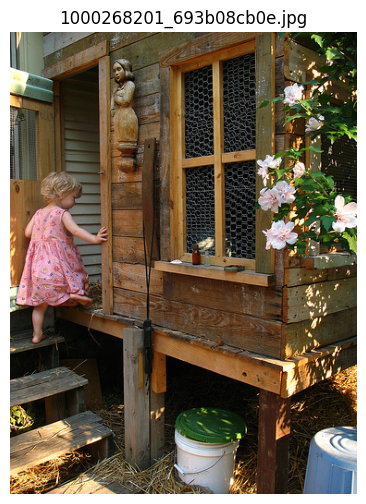

GROUND TRUTH CAPTIONS

- A child in a pink dress is climbing up a set of stairs in an entry way .
- A girl going into a wooden building .
- A little girl climbing into a wooden playhouse .
- A little girl climbing the stairs to her playhouse .
- A little girl in a pink dress going into a wooden cabin .

TOP 5 RETRIEVED CAPTIONS

1. A little girl in a pink dress going into a wooden cabin .
2. A little girl climbing the stairs to her playhouse .
3. A little girl climbing into a wooden playhouse .
4. A child in a pink dress is climbing up a set of stairs in an entry way .
5. A barefoot red-headed girl jumping over a rail .


In [64]:
# image to text
from PIL import Image
import matplotlib.pyplot as plt

image_idx = 0

img_name = image_ids[image_idx]
img_path = f"/content/flickr8k/Images/{img_name}"

# Display image
img = Image.open(img_path)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title(img_name)
plt.show()

# Ground Truth
print("GROUND TRUTH CAPTIONS\n")

for idx in image_to_captions[img_name]:
    print("-", subset.iloc[idx]["caption"])

# Retrieved captions
scores = similarity_matrix[image_idx]

top5 = scores.argsort()[-5:][::-1]

print("\nTOP 5 RETRIEVED CAPTIONS\n")

for rank, cap_idx in enumerate(top5):

    print(
        f"{rank+1}.",
        subset.iloc[cap_idx]["caption"]
    )

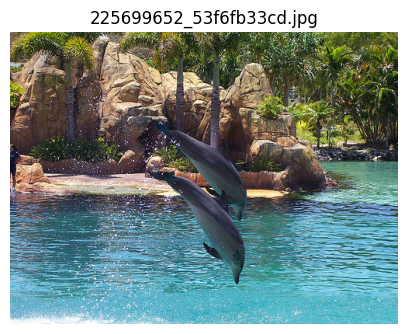

Top 5 Captions:
1. Two dolphins jumped out of the water in this zoo .
2. Two dolphins jump out of the blue water with palm trees behind them .
3. Two dolphins jumping into the water .
4. Two dolphins jump out of the water together .
5. Two dolphins flying headfirst into a beautiful tropical blue lake




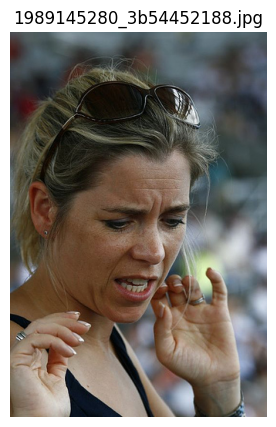

Top 5 Captions:
1. A woman scratching her face .
2. A girl in a grey shirt puts her hands over her head in a gesture .
3. A woman wearing a white glove peers over the crowd .
4. A person in white makeup and clothes blowing a whistle .
5. An upset woman with her makeup streaming down her face from her tears .




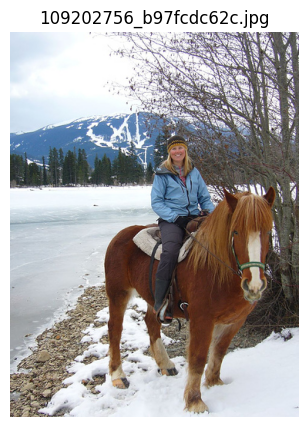

Top 5 Captions:
1. A woman dressed in a blue jacket and blue jeans rides a brown horse near a frozen lake and snow-covered mountain .
2. A young blond woman sitting atop a brown draft horse in the snowy mountains .
3. Woman n blue jacket sits on daft horse near a frozen lake .
4. A woman rides a horse near a frozen lake in the wintertime .
5. A woman in a blue jacket rides a brown pony near water .




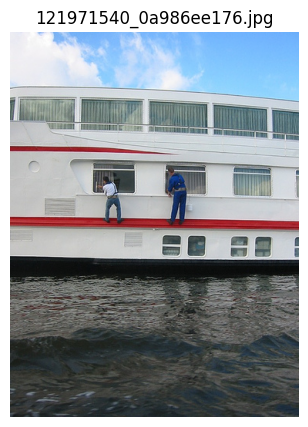

Top 5 Captions:
1. two men cleaning the outside windows of a yacht
2. Two people stand on the side of a large white and red boat .
3. Two people outside cleaning windows while on a ledge of a boat .
4. Three people stand on a boat that is docked .
5. Three people are standing on the dock of a boat looking at something off camera .




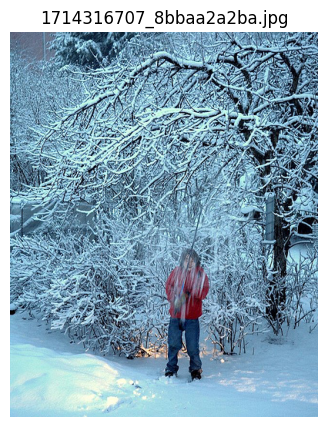

Top 5 Captions:
1. A person in a red jacket stands under a snow-covered tree .
2. A boy in a red jacket smacks a snow covered tree with a stick .
3. Child standing in a snowy landscape pulling down a snow-covered tree branch .
4. A child stands underneath a snow-covered tree .
5. A person wearing a red jacket climbs a snowy hill .




In [65]:
# image to text -> Random 5 images
import random

sample_images = random.sample(
    range(len(image_ids)),
    5
)

for image_idx in sample_images:

    img_name = image_ids[image_idx]

    img = Image.open(
        f"/content/flickr8k/Images/{img_name}"
    )

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_name)
    plt.show()

    scores = similarity_matrix[image_idx]

    top5 = scores.argsort()[-5:][::-1]

    print("Top 5 Captions:")

    for rank, cap_idx in enumerate(top5):

        print(
            f"{rank+1}.",
            subset.iloc[cap_idx]["caption"]
        )

    print("\n" + "="*80 + "\n")

QUERY:
A child in a pink dress is climbing up a set of stairs in an entry way .


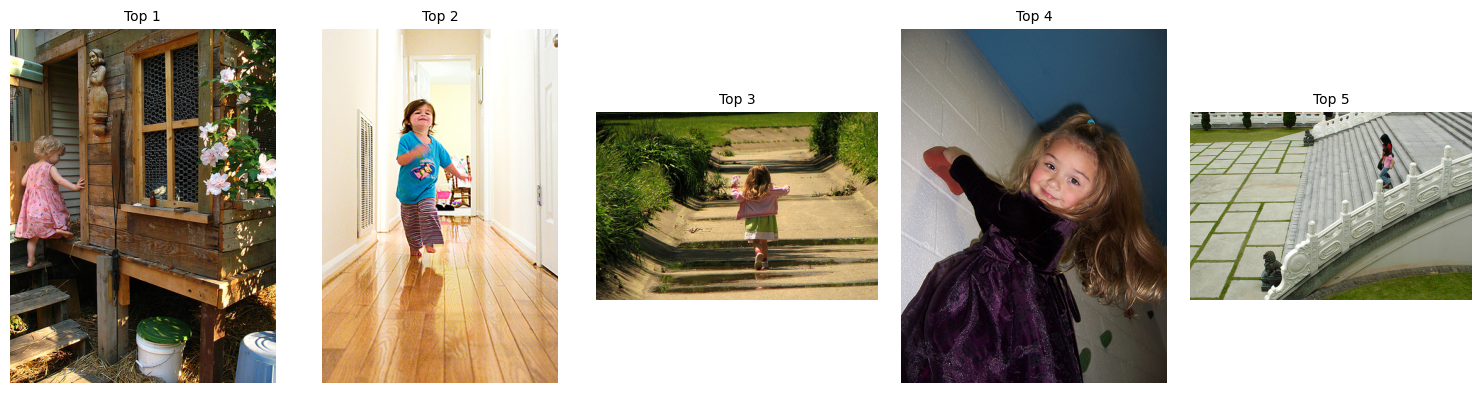

In [66]:
# text to image
caption_idx = 0

query_caption = subset.iloc[
    caption_idx
]["caption"]

print("QUERY:")
print(query_caption)

scores = text_to_image_matrix[
    caption_idx
]

top5 = scores.argsort()[-5:][::-1]

plt.figure(figsize=(15,4))

for i, img_idx in enumerate(top5):

    img_name = image_ids[img_idx]

    img = Image.open(
        f"/content/flickr8k/Images/{img_name}"
    )

    plt.subplot(1,5,i+1)

    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"Top {i+1}",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [67]:
# Text to Image -> Random 5 texts
import random

sample_caps = random.sample(
    range(len(subset)),
    5
)

for caption_idx in sample_caps:

    query_caption = subset.iloc[
        caption_idx
    ]["caption"]

    print("\nQUERY:")
    print(query_caption)

    scores = text_to_image_matrix[
        caption_idx
    ]

    top5 = scores.argsort()[-5:][::-1]

    plt.figure(figsize=(15,4))

    for i, img_idx in enumerate(top5):

        img_name = image_ids[img_idx]

        img = Image.open(
            f"/content/flickr8k/Images/{img_name}"
        )

        plt.subplot(1,5,i+1)

        plt.imshow(img)
        plt.axis("off")

        plt.title(
            f"Top {i+1}",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

    print("\n" + "="*100 + "\n")

Output hidden; open in https://colab.research.google.com to view.

In [68]:
#Text to text
query_idx = 0

scores = text_similarity[
    query_idx
].copy()

scores[query_idx] = -1

top5 = scores.argsort()[-5:][::-1]

print("QUERY:\n")
print(subset.iloc[query_idx]["caption"])

print("\nTOP 5 RETRIEVED:\n")

for rank, idx in enumerate(top5):

    print(
        f"{rank+1}.",
        subset.iloc[idx]["caption"]
    )

QUERY:

A child in a pink dress is climbing up a set of stairs in an entry way .

TOP 5 RETRIEVED:

1. A little girl in a pink dress going into a wooden cabin .
2. people in red and pink walking down large steps
3. A little girl climbing the stairs to her playhouse .
4. The girl in a bright pink skirt dances near a stroller .
5. A baby in a white and pink dress walks outside .
